# Homework 5 Problem 1: ViT vs. ResNet-18

**Course:** ECGR 4106  
**Student:** Gilberto Feliu  
**Student ID:** 801257813  
**Dataset:** CIFAR-100

This notebook reports the current Problem 1 experiment artifacts from `Results_Problem_1`. Problem 1 now has completed 10-epoch rows for all four ViT configurations and the ResNet-18 baseline.

## Experiment Setup

The custom Vision Transformer uses convolutional patch embedding, a learned class token, learned positional embeddings, `nn.TransformerEncoderLayer` blocks, layer normalization, and a linear classifier head for 100 CIFAR-100 classes. The ResNet-18 baseline uses `torchvision.models.resnet18(weights=None)` with the first convolution changed for 32 by 32 CIFAR images and the initial max-pooling layer removed.

All runs use CIFAR-100 normalization, Adam optimization, cross-entropy loss, batch size 64, and a 10-epoch schedule. The current CSV contains the completed 10-epoch Problem 1 results.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
RESULTS = ROOT / 'Results_Problem_1'
history_path = RESULTS / 'problem1_history.csv'
summary_path = RESULTS / 'problem1_summary.csv'
plot_path = RESULTS / 'problem1_loss_curves.png'
tradeoff_path = RESULTS / 'problem1_tradeoffs.png'
print('Summary:', summary_path)
print('History:', history_path)
print('Training plot:', plot_path)
print('Tradeoff plot:', tradeoff_path)

Summary: /home/gilberto/Homework_5/Results_Problem_1/problem1_summary.csv
History: /home/gilberto/Homework_5/Results_Problem_1/problem1_history.csv
Training plot: /home/gilberto/Homework_5/Results_Problem_1/problem1_loss_curves.png
Tradeoff plot: /home/gilberto/Homework_5/Results_Problem_1/problem1_tradeoffs.png


## Full Problem 1 Source Code

The complete Python script used for this problem is shown below as one contiguous code block. The same source file is stored at `src/hw5_vit_resnet.py`.

```python
from __future__ import annotations

import argparse
import csv
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms


torch.set_num_threads(2)
SEED = 4106
ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "Results_Problem_1"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 32
NUM_CLASSES = 100


@dataclass
class ExperimentConfig:
    model_name: str
    patch_size: int | None
    embed_dim: int | None
    depth: int | None
    heads: int | None
    mlp_dim: int | None
    batch_size: int
    epochs: int
    learning_rate: float


@dataclass
class ExperimentResult:
    model_name: str
    patch_size: int | None
    embed_dim: int | None
    depth: int | None
    heads: int | None
    mlp_dim: int | None
    parameter_count: int | None
    flops_forward: float | None
    train_time_per_epoch_sec: float | None
    final_train_loss: float | None
    final_val_loss: float | None
    test_accuracy_pct: float | None
    notes: str = ""


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dirs() -> None:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def count_parameters(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    predictions = logits.argmax(dim=1)
    return 100.0 * predictions.eq(targets).sum().item() / max(1, targets.numel())


class PatchEmbedding(nn.Module):
    def __init__(self, image_size: int, patch_size: int, in_channels: int, embed_dim: int) -> None:
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError("image_size must be divisible by patch_size")
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class ViTClassifier(nn.Module):
    def __init__(
        self,
        image_size: int = IMAGE_SIZE,
        patch_size: int = 4,
        in_channels: int = 3,
        num_classes: int = NUM_CLASSES,
        embed_dim: int = 256,
        depth: int = 4,
        heads: int = 4,
        mlp_dim: int = 1024,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self._reset_parameters()

    def _reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embedding[:, : x.size(1)]
        x = self.encoder(x)
        x = self.norm(x[:, 0])
        return self.head(x)


def build_resnet18(num_classes: int = NUM_CLASSES) -> nn.Module:
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def get_cifar100_loaders(batch_size: int, num_workers: int = 0) -> tuple[DataLoader, DataLoader]:
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    train_dataset = datasets.CIFAR100(root=DATA_DIR, train=True, download=True, transform=train_transform)
    test_dataset = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=test_transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    return train_loader, test_loader


def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            logits = model(inputs)
            loss = criterion(logits, targets)
            total_loss += loss.item() * targets.size(0)
            total_correct += logits.argmax(dim=1).eq(targets).sum().item()
            total_samples += targets.size(0)
    return {
        "loss": total_loss / max(1, total_samples),
        "accuracy_pct": 100.0 * total_correct / max(1, total_samples),
    }


def train_model(model: nn.Module, config: ExperimentConfig, train_loader: DataLoader, test_loader: DataLoader) -> tuple[list[dict[str, float]], ExperimentResult]:
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    criterion = nn.CrossEntropyLoss()
    history: list[dict[str, float]] = []
    start_all = time.perf_counter()
    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
        start_epoch = time.perf_counter()
        for inputs, targets in train_loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_correct += logits.argmax(dim=1).eq(targets).sum().item()
            total_samples += targets.size(0)
        test_metrics = evaluate_model(model, test_loader, criterion)
        history.append({
            "model_name": config.model_name,
            "epoch": epoch,
            "train_loss": total_loss / max(1, total_samples),
            "val_loss": test_metrics["loss"],
            "train_accuracy_pct": 100.0 * total_correct / max(1, total_samples),
            "val_accuracy_pct": test_metrics["accuracy_pct"],
            "epoch_seconds": time.perf_counter() - start_epoch,
        })
        latest = history[-1]
        print(
            f"{config.model_name} epoch {epoch}/{config.epochs}: "
            f"train_loss={latest['train_loss']:.4f}, "
            f"val_loss={latest['val_loss']:.4f}, "
            f"val_acc={latest['val_accuracy_pct']:.2f}%, "
            f"seconds={latest['epoch_seconds']:.1f}",
            flush=True,
        )

    average_epoch_seconds = (time.perf_counter() - start_all) / max(1, config.epochs)
    final = history[-1]
    result = ExperimentResult(
        model_name=config.model_name,
        patch_size=config.patch_size,
        embed_dim=config.embed_dim,
        depth=config.depth,
        heads=config.heads,
        mlp_dim=config.mlp_dim,
        parameter_count=count_parameters(model),
        flops_forward=estimate_flops(config),
        train_time_per_epoch_sec=average_epoch_seconds,
        final_train_loss=final["train_loss"],
        final_val_loss=final["val_loss"],
        test_accuracy_pct=final["val_accuracy_pct"],
        notes=f"device={DEVICE.type}",
    )
    return history, result


def estimate_flops(config: ExperimentConfig) -> float | None:
    if config.model_name == "resnet18":
        # CIFAR-adapted ResNet-18: 3x3 stride-1 stem and no initial max pool.
        return 555_468_800.0
    if config.patch_size is None or config.embed_dim is None or config.depth is None or config.heads is None or config.mlp_dim is None:
        return None
    tokens = (IMAGE_SIZE // config.patch_size) ** 2 + 1
    d = config.embed_dim
    depth = config.depth
    attn = depth * (4 * tokens * d * d + 2 * tokens * tokens * d)
    mlp = depth * (2 * tokens * d * config.mlp_dim)
    head = d * NUM_CLASSES
    return float(attn + mlp + head)


def append_history_rows(rows: list[dict[str, float]]) -> None:
    history_path = RESULTS_DIR / "problem1_history.csv"
    exists = history_path.exists()
    with history_path.open("a", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        if not exists or history_path.stat().st_size == 0:
            writer.writeheader()
        for row in rows:
            writer.writerow(row)


def write_summary(rows: list[ExperimentResult]) -> None:
    summary_path = RESULTS_DIR / "problem1_summary.csv"
    with summary_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(asdict(rows[0]).keys()))
        writer.writeheader()
        for row in rows:
            writer.writerow(asdict(row))


def default_vit_configs() -> list[ExperimentConfig]:
    return [
        ExperimentConfig("vit_patch4_dim256_d4_h4", 4, 256, 4, 4, 1024, 64, 10, 1e-3),
        ExperimentConfig("vit_patch4_dim512_d8_h8", 4, 512, 8, 8, 2048, 64, 10, 1e-3),
        ExperimentConfig("vit_patch8_dim256_d4_h4", 8, 256, 4, 4, 1024, 64, 10, 1e-3),
        ExperimentConfig("vit_patch8_dim512_d8_h8", 8, 512, 8, 8, 2048, 64, 10, 1e-3),
    ]


def build_vit_from_config(config: ExperimentConfig) -> ViTClassifier:
    return ViTClassifier(
        patch_size=config.patch_size or 4,
        embed_dim=config.embed_dim or 256,
        depth=config.depth or 4,
        heads=config.heads or 4,
        mlp_dim=config.mlp_dim or 1024,
    )


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Homework 5 Problem 1: ViT vs ResNet-18")
    parser.add_argument("--run-all-vit", action="store_true")
    parser.add_argument("--run-vit", type=str, default=None, help="Specific ViT config name to run")
    parser.add_argument("--run-resnet", action="store_true")
    parser.add_argument("--epochs", type=int, default=None)
    parser.add_argument("--batch-size", type=int, default=None)
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument("--reset-history", action="store_true")
    return parser.parse_args()


def maybe_reset_history() -> None:
    history_path = RESULTS_DIR / "problem1_history.csv"
    if history_path.exists():
        history_path.unlink()


def select_vit_configs(args: argparse.Namespace) -> list[ExperimentConfig]:
    configs = default_vit_configs()
    if args.run_vit:
        configs = [config for config in configs if config.model_name == args.run_vit]
        if not configs:
            raise ValueError(f"Unknown ViT config: {args.run_vit}")
    if args.epochs is not None or args.batch_size is not None:
        updated: list[ExperimentConfig] = []
        for config in configs:
            updated.append(ExperimentConfig(
                model_name=config.model_name,
                patch_size=config.patch_size,
                embed_dim=config.embed_dim,
                depth=config.depth,
                heads=config.heads,
                mlp_dim=config.mlp_dim,
                batch_size=args.batch_size or config.batch_size,
                epochs=args.epochs or config.epochs,
                learning_rate=config.learning_rate,
            ))
        configs = updated
    return configs


def run_vit_experiments(args: argparse.Namespace) -> list[ExperimentResult]:
    results: list[ExperimentResult] = []
    for config in select_vit_configs(args):
        train_loader, test_loader = get_cifar100_loaders(config.batch_size, args.num_workers)
        history, result = train_model(build_vit_from_config(config), config, train_loader, test_loader)
        append_history_rows(history)
        results.append(result)
    return results


def run_resnet_experiment(args: argparse.Namespace) -> ExperimentResult:
    batch_size = args.batch_size or 64
    epochs = args.epochs or 10
    config = ExperimentConfig("resnet18", None, None, None, None, None, batch_size, epochs, 1e-3)
    train_loader, test_loader = get_cifar100_loaders(config.batch_size, args.num_workers)
    history, result = train_model(build_resnet18(), config, train_loader, test_loader)
    append_history_rows(history)
    return result


def refresh_summary_with_results(results: list[ExperimentResult]) -> None:
    summary_path = RESULTS_DIR / "problem1_summary.csv"
    if summary_path.exists():
        existing = pd.read_csv(summary_path)
        by_name = {result.model_name: asdict(result) for result in results}
        rows = []
        for record in existing.to_dict(orient="records"):
            if record["model_name"] in by_name:
                rows.append(by_name[record["model_name"]])
            else:
                rows.append(record)
        final_rows = [ExperimentResult(**row) for row in rows]
        write_summary(final_rows)
        return
    write_summary(results)


def main() -> None:
    args = parse_args()
    set_seed()
    ensure_dirs()
    if args.reset_history:
        maybe_reset_history()

    collected: list[ExperimentResult] = []
    if args.run_all_vit or args.run_vit:
        collected.extend(run_vit_experiments(args))
    if args.run_resnet:
        collected.append(run_resnet_experiment(args))

    if not collected:
        print("Nothing ran. Use --run-all-vit, --run-vit <name>, or --run-resnet.")
        return

    refresh_summary_with_results(collected)
    print(pd.DataFrame([asdict(result) for result in collected]).to_string(index=False))


if __name__ == "__main__":
    main()

```


## Summary Results

The table below is read directly from `Results_Problem_1/problem1_summary.csv`. Every planned row includes completed 10-epoch training metrics, parameter counts, and FLOP estimates.

In [2]:
summary_df = pd.read_csv(summary_path, keep_default_na=False)
summary_df

,model_name,patch_size,embed_dim,depth,heads,mlp_dim,parameter_count,flops_forward,train_time_per_epoch_sec,final_train_loss,final_val_loss,test_accuracy_pct,notes
0,vit_patch4_dim256_d4_h4,4,256,4,4,1024,3214692,2.131507e+08,23.014994,3.325062,3.283429,20.01,device=cuda
1,vit_patch4_dim512_d8_h8,4,512,8,8,2048,25330276,1.670441e+09,106.715145,4.303222,4.323157,4.51,device=cuda
2,vit_patch8_dim256_d4_h4,8,256,4,4,1024,3239268,5.409485e+07,12.217159,3.902182,3.885059,9.68,device=cuda
3,vit_patch8_dim512_d8_h8,8,512,8,8,2048,25379428,4.302377e+08,42.299152,4.227836,4.269351,4.95,device=cuda
4,resnet18,,,,,,11220132,5.554688e+08,61.236564,1.048969,1.391882,61.20,device=cuda


## Clean Report Table

In [3]:
report_cols = [
    'model_name', 'parameter_count', 'flops_forward',
    'train_time_per_epoch_sec', 'final_val_loss', 'test_accuracy_pct', 'notes'
]
report_df = summary_df[report_cols].copy()
report_df.columns = ['Model', 'Params', 'FLOPs / Forward', 'Time / Epoch (s)', 'Final Val Loss', 'Test Accuracy (%)', 'Status']
report_df

,Model,Params,FLOPs / Forward,Time / Epoch (s),Final Val Loss,Test Accuracy (%),Status
0,vit_patch4_dim256_d4_h4,3214692,2.131507e+08,23.014994,3.283429,20.01,device=cuda
1,vit_patch4_dim512_d8_h8,25330276,1.670441e+09,106.715145,4.323157,4.51,device=cuda
2,vit_patch8_dim256_d4_h4,3239268,5.409485e+07,12.217159,3.885059,9.68,device=cuda
3,vit_patch8_dim512_d8_h8,25379428,4.302377e+08,42.299152,4.269351,4.95,device=cuda
4,resnet18,11220132,5.554688e+08,61.236564,1.391882,61.20,device=cuda


## Per-Epoch History

A full Problem 1 run should produce about 50 data rows: 5 models times 10 epochs. The current history file contains the completed Problem 1 runs.

In [4]:
history_df = pd.read_csv(history_path)
print(f'History rows: {len(history_df)}')
history_df

History rows: 50


,model_name,epoch,train_loss,val_loss,train_accuracy_pct,val_accuracy_pct,epoch_seconds
0,vit_patch4_dim256_d4_h4,1,4.010155,3.759034,7.828,11.36,23.015639
1,vit_patch4_dim256_d4_h4,2,3.738646,3.665595,11.850,13.50,22.786489
2,vit_patch4_dim256_d4_h4,3,3.640890,3.556376,13.436,14.62,22.918571
3,vit_patch4_dim256_d4_h4,4,3.606052,3.507664,14.038,16.03,23.130308
4,vit_patch4_dim256_d4_h4,5,3.554222,3.522711,14.900,16.13,23.087703
5,vit_patch4_dim256_d4_h4,6,3.535617,3.425678,15.396,17.34,22.934365
6,vit_patch4_dim256_d4_h4,7,3.436794,3.465146,17.226,17.02,22.914715
7,vit_patch4_dim256_d4_h4,8,3.438895,3.348804,17.018,18.73,23.025334
8,vit_patch4_dim256_d4_h4,9,3.347852,3.299602,18.770,19.72,23.194426
9,vit_patch4_dim256_d4_h4,10,3.325062,3.283429,19.102,20.01,23.141071


## Training and Tradeoff Figures

### Loss and Accuracy Curves

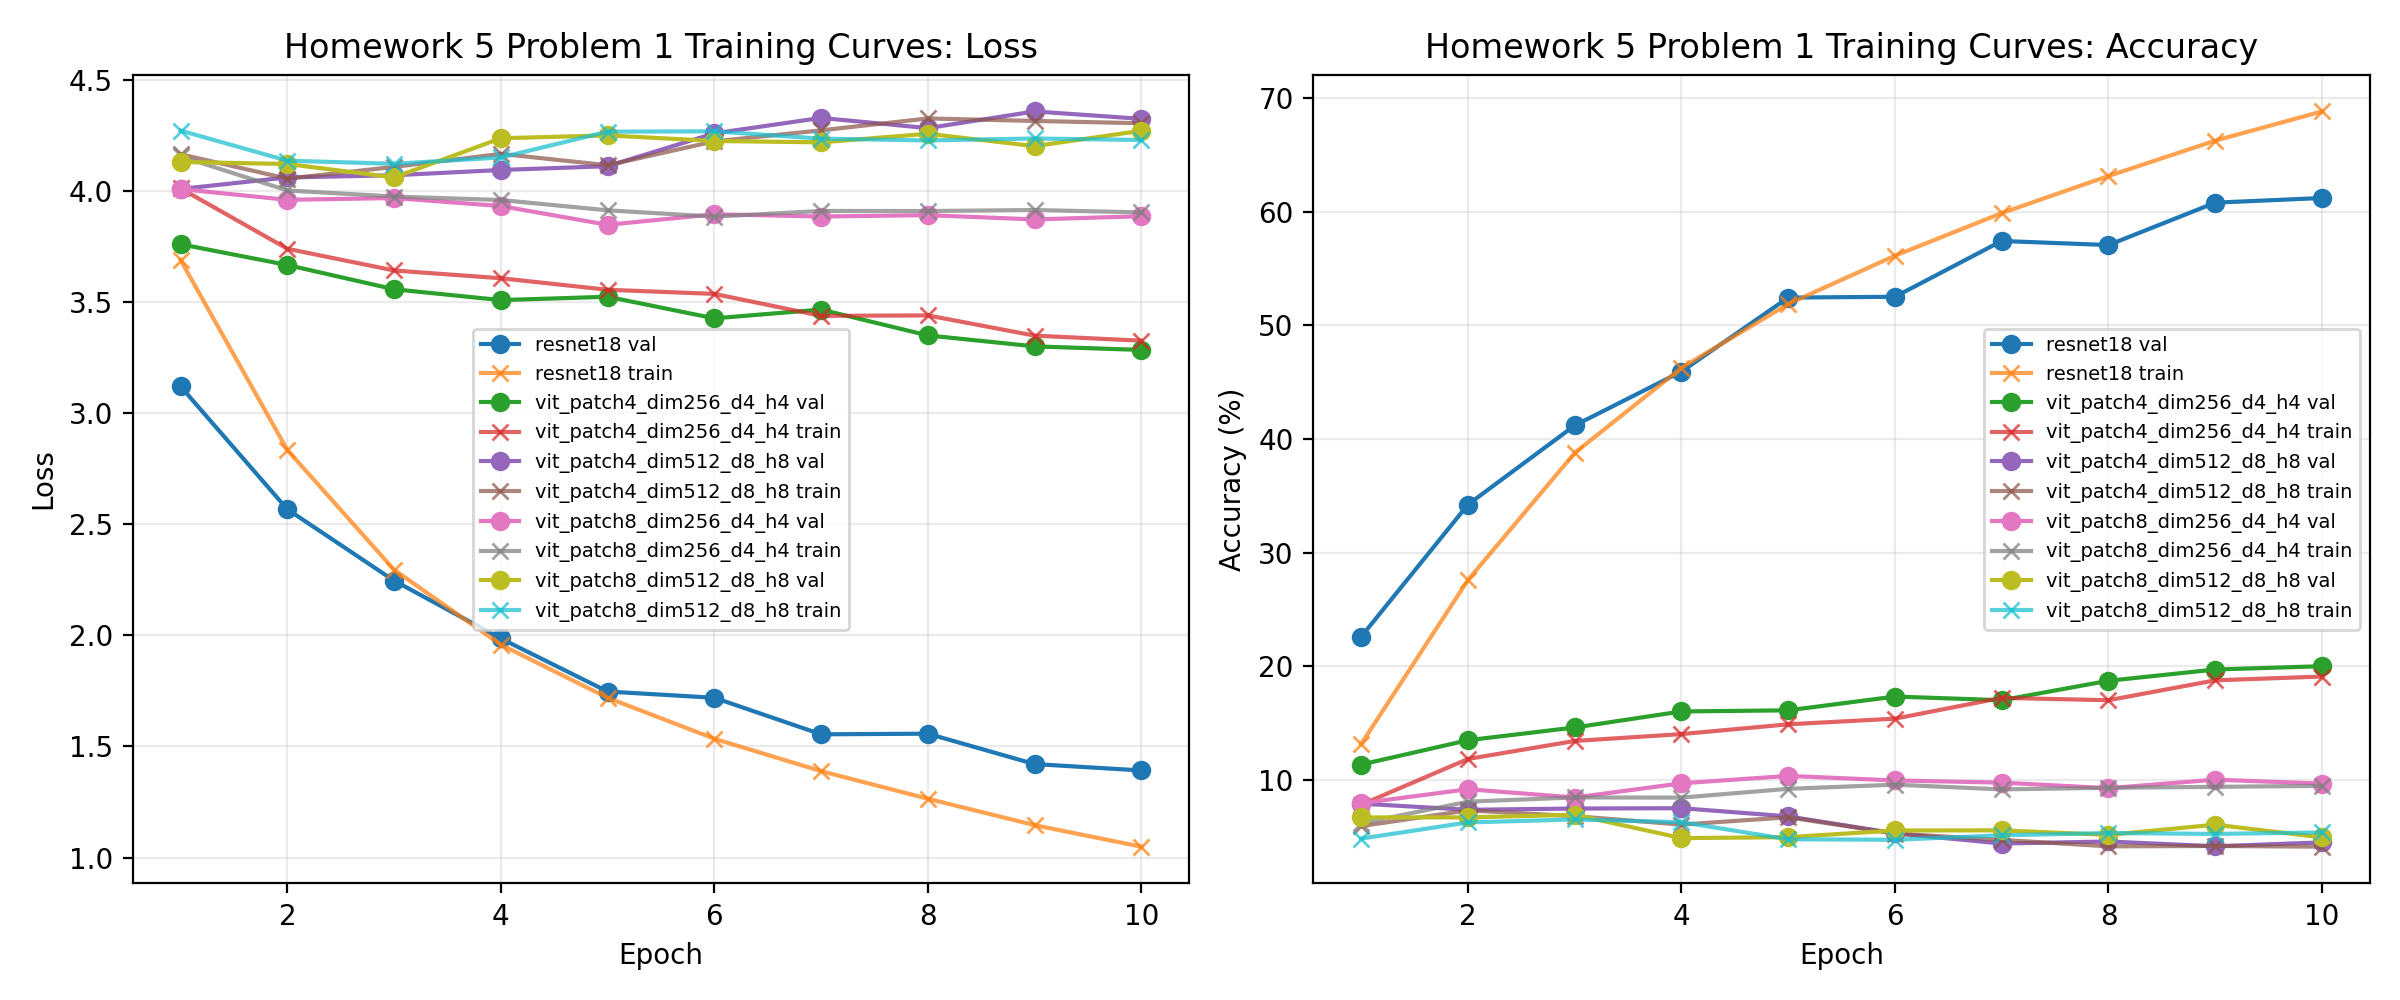

### Accuracy, Runtime, and Compute Tradeoffs

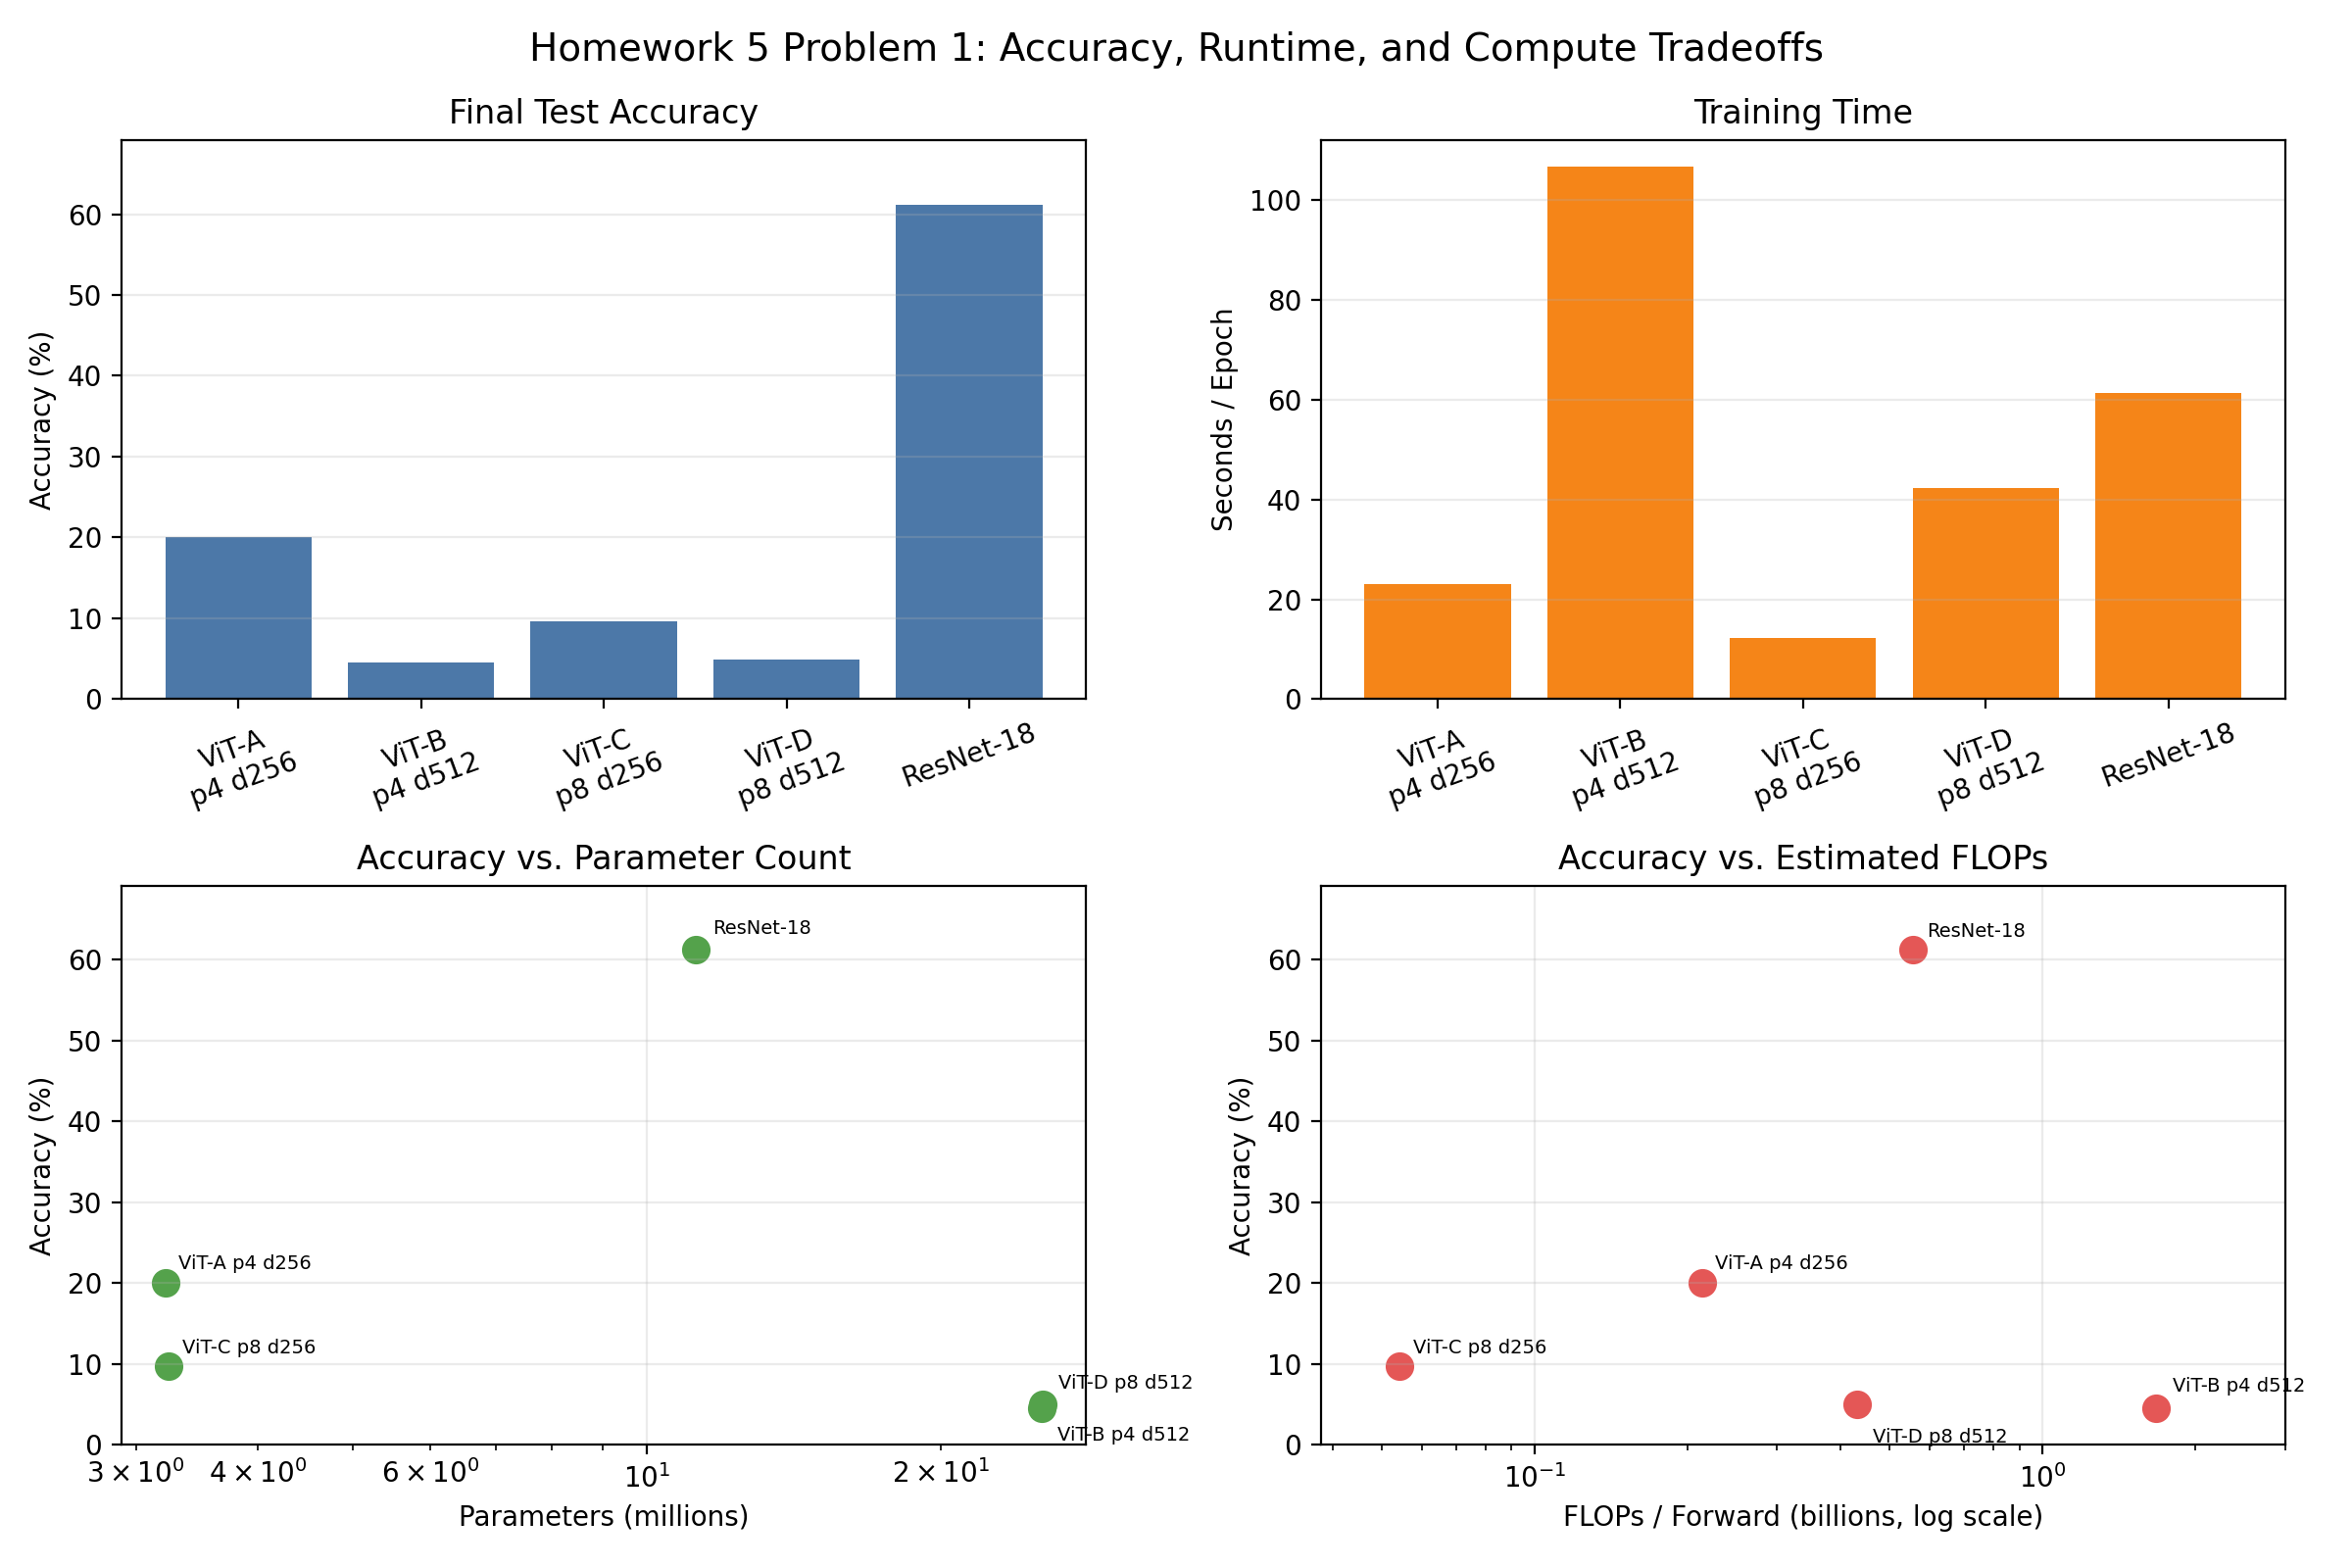

In [5]:
display(Markdown('### Loss and Accuracy Curves'))
display(Image(filename=str(plot_path)))
display(Markdown('### Accuracy, Runtime, and Compute Tradeoffs'))
display(Image(filename=str(tradeoff_path)))

## Interpretation

Among the ViT models, `vit_patch4_dim256_d4_h4` performs best at 20.01% test accuracy. `vit_patch8_dim256_d4_h4` is the next best ViT at 9.68% and has the lowest estimated FLOP count. Comparing those two rows isolates the patch-size effect: both use embedding dimension 256, depth 4, and 4 heads, but the 8 by 8 patch model uses far fewer tokens, lowers FLOPs from 2.13e8 to 5.41e7, and loses accuracy because it preserves less fine spatial detail.

Increasing model capacity did not improve the from-scratch ViTs under the short 10-epoch schedule. `vit_patch4_dim512_d8_h8` has many more parameters and FLOPs than `vit_patch4_dim256_d4_h4`, but its accuracy falls to 4.51%. The same pattern appears for the 8 by 8 patch pair. The training curves show that the larger ViTs stay near high cross-entropy loss and low accuracy, so their poor final results are consistent with under-optimization rather than a missing metric.

The ResNet-18 baseline is strongest overall at 61.20% test accuracy. Its train and validation losses decrease steadily across the plotted run, which verifies that the model is training properly. That is consistent with convolutional inductive bias helping on CIFAR-100, while from-scratch ViTs generally need longer schedules, stronger regularization, or pretraining.